In [1]:
import os
import glob
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader, random_split

Loading in Data

In [2]:
try:
    import tifffile
    TIFFFILE_AVAILABLE = True
except ImportError:
    TIFFFILE_AVAILABLE = False

In [3]:
# -----------------------------------
# 1. File loading helpers
# -----------------------------------

def load_tif_image(path: str) -> np.ndarray:
    if TIFFFILE_AVAILABLE:
        try:
            img = tifffile.imread(path)
        except Exception:
            img = np.array(Image.open(path))
    else:
        img = np.array(Image.open(path))

    img = np.asarray(img)

    if img.ndim == 2:
        pass
    elif img.ndim == 3:
        if img.shape[0] < min(img.shape[1], img.shape[2]):
            img = img.mean(axis=0)
        else:
            img = img.mean(axis=-1)
    else:
        raise ValueError(f"Unsupported image shape {img.shape} for file {path}")

    return img.astype(np.float32)


def load_mask_image(path: str) -> np.ndarray:
    mask = np.array(Image.open(path))
    if mask.ndim == 3:
        mask = mask[..., 0]
    return (mask > 0).astype(np.float32)

In [4]:
# -----------------------------------
# 2. Preprocessing helpers
# -----------------------------------

def percentile_normalize(img: np.ndarray, lower: float = 1, upper: float = 99) -> np.ndarray:
    lo = np.percentile(img, lower)
    hi = np.percentile(img, upper)

    if hi <= lo:
        img = img - img.min()
        denom = img.max()
        if denom > 0:
            img = img / denom
        return img.astype(np.float32)

    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo)
    return img.astype(np.float32)


def resize_image_and_mask(image: np.ndarray, mask: np.ndarray, size=(256, 256)):
    image_pil = Image.fromarray((image * 255).astype(np.uint8))
    mask_pil = Image.fromarray((mask * 255).astype(np.uint8))

    image_resized = image_pil.resize(size, Image.BILINEAR)
    mask_resized = mask_pil.resize(size, Image.NEAREST)

    image_out = np.array(image_resized).astype(np.float32) / 255.0
    mask_out = (np.array(mask_resized) > 0).astype(np.float32)

    return image_out, mask_out

In [5]:
# -----------------------------------
# 3. CSV parsing + prefix extraction
# -----------------------------------

def load_counts_csv(count_csv_path: str) -> pd.DataFrame:
    """
    Load the counts CSV correctly.

    The file has 4 real columns, but each row also has a trailing comma.
    So we explicitly keep only the first 4 columns.
    """
    df = pd.read_csv(
        count_csv_path,
        index_col=False,
        usecols=[0, 1, 2, 3]
    )

    # Clean whitespace
    df.columns = [c.strip() for c in df.columns]

    required = ["Image_Count_Nuclei", "Image_FileName_OrigDAPI"]
    for col in required:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    df["Image_FileName_OrigDAPI"] = df["Image_FileName_OrigDAPI"].astype(str).str.strip()
    df["Image_Count_Nuclei"] = pd.to_numeric(df["Image_Count_Nuclei"], errors="coerce")

    df = df.dropna(subset=["Image_Count_Nuclei", "Image_FileName_OrigDAPI"]).copy()
    df["Image_Count_Nuclei"] = df["Image_Count_Nuclei"].astype(int)

    return df


def get_prefix_from_raw_filename(raw_filename: str) -> str:
    """
    Example:
    mcf-z-stacks-03212011_a01_s1_w29fd6a02-....tif
    -> mcf-z-stacks-03212011_a01_s1
    """
    stem = Path(raw_filename).stem
    if "_w" not in stem:
        raise ValueError(f"Filename does not contain '_w': {raw_filename}")
    return stem.split("_w")[0]

In [6]:
df = load_counts_csv("BBBC006_v1_counts.csv")
print(df.head())
print("rows:", len(df))
print(df.columns.tolist())

   Image_Count_Nuclei                            Image_FileName_OrigDAPI  \
0                   7  mcf-z-stacks-03212011_a01_s1_w197083f74-b742-4...   
1                  18  mcf-z-stacks-03212011_a01_s2_w1a63ef720-8648-4...   
2                  68  mcf-z-stacks-03212011_a02_s1_w1ebe36734-a690-4...   
3                  80  mcf-z-stacks-03212011_a02_s2_w1376ffd1a-e96b-4...   
4                  11  mcf-z-stacks-03212011_a03_s1_w1554aa323-1f38-4...   

   Image_Metadata_Site Image_Metadata_Well  
0                    1                 a01  
1                    2                 a01  
2                    1                 a02  
3                    2                 a02  
4                    1                 a03  
rows: 768
['Image_Count_Nuclei', 'Image_FileName_OrigDAPI', 'Image_Metadata_Site', 'Image_Metadata_Well']


In [7]:
# -----------------------------------
# 4. Dataset
# -----------------------------------

class NucleiSegmentationDataset(Dataset):
    def __init__(
        self,
        raw_dir: str,
        mask_dir: str,
        count_csv_path: str,
        image_size=(256, 256),
        return_original_size: bool = False,
        verbose: bool = True
    ):
        self.raw_dir = Path(raw_dir)
        self.mask_dir = Path(mask_dir)
        self.image_size = image_size
        self.return_original_size = return_original_size
        self.verbose = verbose

        self.df = load_counts_csv(count_csv_path)
        self.samples = self._build_samples()

        if len(self.samples) == 0:
            raise ValueError("No valid raw/mask/count matches found.")

    def _build_samples(self):
        samples = []

        # Build raw prefix -> list of candidate raw files
        raw_files = sorted(list(self.raw_dir.glob("*.tif")) + list(self.raw_dir.glob("*.tiff")))
        raw_prefix_to_files = {}

        for raw_path in raw_files:
            try:
                prefix = get_prefix_from_raw_filename(raw_path.name)
            except ValueError:
                continue
            raw_prefix_to_files.setdefault(prefix, []).append(raw_path)

        # Build mask lookup by stem
        mask_files = sorted(self.mask_dir.glob("*.png"))
        mask_stem_to_path = {m.stem: m for m in mask_files}

        unmatched_csv = 0
        unmatched_mask = 0
        unmatched_raw = 0

        for _, row in self.df.iterrows():
            raw_filename_from_csv = row["Image_FileName_OrigDAPI"]
            count = int(row["Image_Count_Nuclei"])

            try:
                prefix = get_prefix_from_raw_filename(raw_filename_from_csv)
            except ValueError:
                unmatched_csv += 1
                continue

            # mask should be prefix + .png
            mask_path = mask_stem_to_path.get(prefix, None)
            if mask_path is None:
                unmatched_mask += 1
                continue

            candidate_raws = raw_prefix_to_files.get(prefix, [])
            if len(candidate_raws) == 0:
                unmatched_raw += 1
                continue

            # Temporary rule: choose first candidate deterministically
            chosen_raw = sorted(candidate_raws)[0]

            samples.append({
                "raw_path": str(chosen_raw),
                "mask_path": str(mask_path),
                "count": count,
                "prefix": prefix,
                "raw_filename": chosen_raw.name,
                "mask_filename": mask_path.name
            })

        if self.verbose:
            print(f"CSV rows: {len(self.df)}")
            print(f"Raw prefixes found: {len(raw_prefix_to_files)}")
            print(f"Mask files found: {len(mask_files)}")
            print(f"Matched samples: {len(samples)}")
            print(f"Skipped rows with bad CSV filename format: {unmatched_csv}")
            print(f"Skipped rows with missing mask: {unmatched_mask}")
            print(f"Skipped rows with missing raw image: {unmatched_raw}")

            # show a few examples
            for s in samples[:5]:
                print(f"MATCH: {s['prefix']} -> raw={s['raw_filename']} | mask={s['mask_filename']} | count={s['count']}")

        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        image = load_tif_image(sample["raw_path"])
        mask = load_mask_image(sample["mask_path"])

        if image.shape != mask.shape:
            raise ValueError(
                f"Shape mismatch for {sample['prefix']}: image {image.shape}, mask {mask.shape}"
            )

        original_size = image.shape

        image = percentile_normalize(image)
        image, mask = resize_image_and_mask(image, mask, self.image_size)

        image_tensor = torch.from_numpy(image).unsqueeze(0).float()
        mask_tensor = torch.from_numpy(mask).unsqueeze(0).float()
        count_tensor = torch.tensor(sample["count"], dtype=torch.float32)

        out = {
            "image": image_tensor,
            "mask": mask_tensor,
            "count": count_tensor,
            "image_name": sample["raw_filename"],
            "mask_name": sample["mask_filename"],
            "prefix": sample["prefix"]
        }

        if self.return_original_size:
            out["original_size"] = original_size

        return out

In [8]:
# -----------------------------------
# 5. Split helpers
# -----------------------------------

def create_data_splits(
    raw_dir: str,
    mask_dir: str,
    count_csv_path: str,
    image_size=(256, 256),
    train_ratio: float = 0.7,
    val_ratio: float = 0.15,
    test_ratio: float = 0.15,
    seed: int = 42
):
    if abs(train_ratio + val_ratio + test_ratio - 1.0) > 1e-8:
        raise ValueError("train_ratio + val_ratio + test_ratio must sum to 1.")

    full_dataset = NucleiSegmentationDataset(
        raw_dir=raw_dir,
        mask_dir=mask_dir,
        count_csv_path=count_csv_path,
        image_size=image_size,
        verbose=True
    )

    n_total = len(full_dataset)
    n_train = int(train_ratio * n_total)
    n_val = int(val_ratio * n_total)
    n_test = n_total - n_train - n_val

    generator = torch.Generator().manual_seed(seed)

    train_dataset, val_dataset, test_dataset = random_split(
        full_dataset,
        [n_train, n_val, n_test],
        generator=generator
    )

    return full_dataset, train_dataset, val_dataset, test_dataset


def create_dataloaders(train_dataset, val_dataset, test_dataset, batch_size=8, num_workers=0):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, val_loader, test_loader

In [9]:
raw_dir = "raw_images"
mask_dir = "labeled_images"
count_csv_path = "BBBC006_v1_counts.csv"

full_dataset, train_dataset, val_dataset, test_dataset = create_data_splits(
    raw_dir=raw_dir,
    mask_dir=mask_dir,
    count_csv_path=count_csv_path,
    image_size=(256, 256),
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    seed=42
)

print("Total matched samples:", len(full_dataset))
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

CSV rows: 768
Raw prefixes found: 4
Mask files found: 4
Matched samples: 4
Skipped rows with bad CSV filename format: 0
Skipped rows with missing mask: 764
Skipped rows with missing raw image: 0
MATCH: mcf-z-stacks-03212011_a01_s1 -> raw=mcf-z-stacks-03212011_a01_s1_w1248254b0-0193-4e11-8762-62b5d2b86216.tif | mask=mcf-z-stacks-03212011_a01_s1.png | count=7
MATCH: mcf-z-stacks-03212011_a01_s2 -> raw=mcf-z-stacks-03212011_a01_s2_w16103c57d-a39e-468b-bb15-d55443c280d9.tif | mask=mcf-z-stacks-03212011_a01_s2.png | count=18
MATCH: mcf-z-stacks-03212011_a10_s1 -> raw=mcf-z-stacks-03212011_a10_s1_w156636015-b90a-4755-b5e9-4ad5c11a244a.tif | mask=mcf-z-stacks-03212011_a10_s1.png | count=31
MATCH: mcf-z-stacks-03212011_a10_s2 -> raw=mcf-z-stacks-03212011_a10_s2_w1892c2650-bdc9-4a35-b3a3-082eab4aed84.tif | mask=mcf-z-stacks-03212011_a10_s2.png | count=30
Total matched samples: 4
Train: 2
Val: 0
Test: 2


Passive Learning Pipeline

In [20]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import copy

In [21]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=(32, 64, 128, 256)):
        super().__init__()

        self.downs = nn.ModuleList()
        self.pools = nn.ModuleList()

        current_in = in_channels
        for feature in features:
            self.downs.append(DoubleConv(current_in, feature))
            self.pools.append(nn.MaxPool2d(kernel_size=2, stride=2))
            current_in = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        self.up_transpose = nn.ModuleList()
        self.ups = nn.ModuleList()

        reversed_features = features[::-1]
        current_in = features[-1] * 2

        for feature in reversed_features:
            self.up_transpose.append(
                nn.ConvTranspose2d(current_in, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature * 2, feature))
            current_in = feature

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down, pool in zip(self.downs, self.pools):
            x = down(x)
            skip_connections.append(x)
            x = pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for i in range(len(self.up_transpose)):
            x = self.up_transpose[i](x)
            skip = skip_connections[i]

            # Handle odd image sizes if needed
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)

            x = torch.cat([skip, x], dim=1)
            x = self.ups[i](x)

        return self.final_conv(x)

In [22]:
def dice_coefficient_from_logits(logits, targets, eps=1e-6):
    """
    Computes Dice coefficient after sigmoid + thresholding.
    logits: [B, 1, H, W]
    targets: [B, 1, H, W]
    """
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1)

    dice = (2.0 * intersection + eps) / (union + eps)
    return dice.mean()


def iou_from_logits(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    iou = (intersection + eps) / (union + eps)
    return iou.mean()


class DiceLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (probs * targets).sum(dim=1)
        union = probs.sum(dim=1) + targets.sum(dim=1)

        dice = (2.0 * intersection + self.eps) / (union + self.eps)
        return 1.0 - dice.mean()


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=1.0, dice_weight=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        return self.bce_weight * self.bce(logits, targets) + self.dice_weight * self.dice(logits, targets)

In [23]:
def train_one_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    n_batches = 0

    for batch in dataloader:
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_dice += dice_coefficient_from_logits(logits.detach(), masks).item()
        running_iou += iou_from_logits(logits.detach(), masks).item()
        n_batches += 1

    return {
        "loss": running_loss / max(n_batches, 1),
        "dice": running_dice / max(n_batches, 1),
        "iou": running_iou / max(n_batches, 1),
    }


@torch.no_grad()
def evaluate(model, dataloader, loss_fn, device):
    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    n_batches = 0

    for batch in dataloader:
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)

        logits = model(images)
        loss = loss_fn(logits, masks)

        running_loss += loss.item()
        running_dice += dice_coefficient_from_logits(logits, masks).item()
        running_iou += iou_from_logits(logits, masks).item()
        n_batches += 1

    return {
        "loss": running_loss / max(n_batches, 1),
        "dice": running_dice / max(n_batches, 1),
        "iou": running_iou / max(n_batches, 1),
    }

In [24]:
def train_segmentation_model(
    model,
    train_loader,
    val_loader,
    device,
    num_epochs=20,
    lr=1e-3,
    weight_decay=1e-5,
    save_path="best_unet_model.pt"
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = BCEDiceLoss()

    best_val_loss = float("inf")
    best_model_state = copy.deepcopy(model.state_dict())

    history = {
        "train_loss": [],
        "train_dice": [],
        "train_iou": [],
        "val_loss": [],
        "val_dice": [],
        "val_iou": [],
    }

    for epoch in range(num_epochs):
        train_metrics = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        val_metrics = evaluate(model, val_loader, loss_fn, device) if len(val_loader) > 0 else {
            "loss": float("nan"),
            "dice": float("nan"),
            "iou": float("nan")
        }

        history["train_loss"].append(train_metrics["loss"])
        history["train_dice"].append(train_metrics["dice"])
        history["train_iou"].append(train_metrics["iou"])

        history["val_loss"].append(val_metrics["loss"])
        history["val_dice"].append(val_metrics["dice"])
        history["val_iou"].append(val_metrics["iou"])

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_metrics['loss']:.4f}, Train Dice: {train_metrics['dice']:.4f}, Train IoU: {train_metrics['iou']:.4f}"
        )

        if not np.isnan(val_metrics["loss"]):
            print(
                f"                  Val   Loss: {val_metrics['loss']:.4f}, Val   Dice: {val_metrics['dice']:.4f}, Val   IoU: {val_metrics['iou']:.4f}"
            )

            if val_metrics["loss"] < best_val_loss:
                best_val_loss = val_metrics["loss"]
                best_model_state = copy.deepcopy(model.state_dict())
                torch.save(best_model_state, save_path)

    # if there was no validation set, save final weights
    if np.isnan(history["val_loss"][0]):
        torch.save(model.state_dict(), save_path)
    else:
        model.load_state_dict(best_model_state)

    return model, history

In [25]:
@torch.no_grad()
def predict_mask(model, image_tensor, device, threshold=0.5):
    """
    image_tensor: [1, H, W] or [B, 1, H, W]
    returns binary mask tensor
    """
    model.eval()

    if image_tensor.ndim == 3:
        image_tensor = image_tensor.unsqueeze(0)

    image_tensor = image_tensor.to(device)
    logits = model(image_tensor)
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    return preds.cpu(), probs.cpu()

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = UNet(in_channels=1, out_channels=1).to(device)

train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset,
    val_dataset,
    test_dataset,
    batch_size=2,
    num_workers=0
)

model, history = train_segmentation_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=20,
    lr=1e-3,
    save_path="best_unet_model.pt"
)

Using device: cpu
Epoch 1/20 | Train Loss: 1.4687, Train Dice: 0.1514, Train IoU: 0.0819
Epoch 2/20 | Train Loss: 1.1439, Train Dice: 0.8982, Train IoU: 0.8153
Epoch 3/20 | Train Loss: 1.0473, Train Dice: 0.8701, Train IoU: 0.7702
Epoch 4/20 | Train Loss: 0.9886, Train Dice: 0.8547, Train IoU: 0.7465
Epoch 5/20 | Train Loss: 0.9376, Train Dice: 0.8579, Train IoU: 0.7514
Epoch 6/20 | Train Loss: 0.9017, Train Dice: 0.8656, Train IoU: 0.7634
Epoch 7/20 | Train Loss: 0.8744, Train Dice: 0.8721, Train IoU: 0.7735
Epoch 8/20 | Train Loss: 0.8525, Train Dice: 0.8775, Train IoU: 0.7821
Epoch 9/20 | Train Loss: 0.8343, Train Dice: 0.8849, Train IoU: 0.7938
Epoch 10/20 | Train Loss: 0.8174, Train Dice: 0.8943, Train IoU: 0.8090
Epoch 11/20 | Train Loss: 0.8025, Train Dice: 0.9041, Train IoU: 0.8251
Epoch 12/20 | Train Loss: 0.7889, Train Dice: 0.9125, Train IoU: 0.8393
Epoch 13/20 | Train Loss: 0.7768, Train Dice: 0.9175, Train IoU: 0.8477
Epoch 14/20 | Train Loss: 0.7657, Train Dice: 0.9201, T

In [27]:
loss_fn = BCEDiceLoss()
test_metrics = evaluate(model, test_loader, loss_fn, device)

print("Test metrics:")
print(test_metrics)

Test metrics:
{'loss': 1.2301087379455566, 'dice': 0.8566138744354248, 'iou': 0.7608494758605957}


In [28]:
sample = full_dataset[0]
pred_mask, pred_prob = predict_mask(model, sample["image"], device)

print("Input image shape:", sample["image"].shape)
print("True mask shape:", sample["mask"].shape)
print("Predicted mask shape:", pred_mask.shape)

Input image shape: torch.Size([1, 256, 256])
True mask shape: torch.Size([1, 256, 256])
Predicted mask shape: torch.Size([1, 1, 256, 256])


In [29]:
import matplotlib.pyplot as plt

def show_prediction(model, dataset, index, device, threshold=0.5):
    sample = dataset[index]
    image = sample["image"]
    true_mask = sample["mask"]

    pred_mask, pred_prob = predict_mask(model, image, device, threshold=threshold)

    image_np = image.squeeze().cpu().numpy()
    true_mask_np = true_mask.squeeze().cpu().numpy()
    pred_mask_np = pred_mask.squeeze().cpu().numpy()
    pred_prob_np = pred_prob.squeeze().cpu().numpy()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(image_np, cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(true_mask_np, cmap="gray")
    plt.title("True Mask")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(pred_prob_np, cmap="gray")
    plt.title("Pred Prob")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(pred_mask_np, cmap="gray")
    plt.title("Pred Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

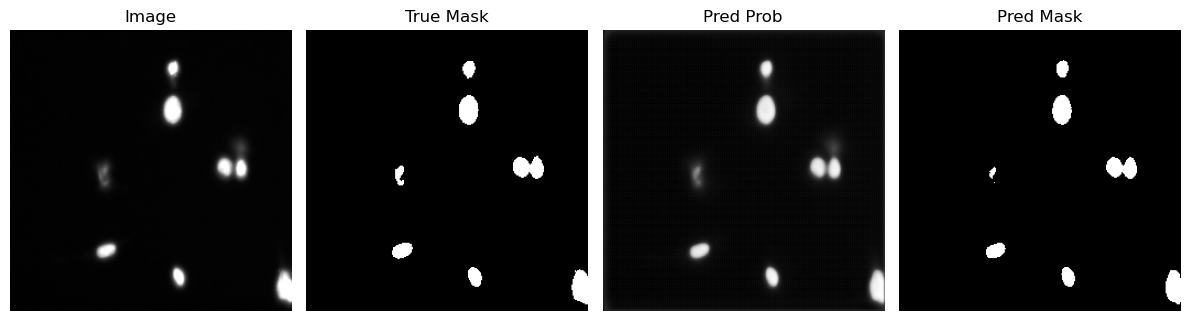

In [30]:
show_prediction(model, full_dataset, index=0, device=device)